In [4]:
!pip install sentencepiece

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 7.9 MB/s eta 0:00:00


In [2]:
###########    Prediction fine tuned model - test_pred ################

import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import classification_report, accuracy_score
import sys
sys.path.append(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper") 
from Analysis_pipeline.intent_train_test_preprocess import preprocess

# Labels used during training (order must match model head)
labels = ['Appreciation', 'Criticism', 'Inquiry', 'Statement']

# Load data once
data = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_test_set.csv")
#data_real = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_test_set.csv")
preprocessed_texts = [preprocess(text) for text in data["text"]]
d = pd.DataFrame({"text": preprocessed_texts})
d = d.apply(lambda row: f"{row['text']}", axis=1).tolist()
Comments = data['text']
# Helper to infer on one model and return a dataframe with logits/probs per label
def run_model_and_collect(model_dir, tok_dir, model_tag, texts, labels, batch_size=32, max_length=512):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
    tokenizer = AutoTokenizer.from_pretrained(tok_dir, use_fast=False)
    model.eval()

    # Storage
    predicted_labels = []
    per_label_logits = {lab: [] for lab in labels}
    per_label_probs  = {lab: [] for lab in labels}

    def get_predictions_for_batch(batch_texts):
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.inference_mode():
            outputs = model(**enc)
            logits_t = outputs.logits.float()                 # (B, L)
            probs_t  = torch.softmax(logits_t, dim=-1)        # (B, L)

        logits = logits_t.cpu().numpy()
        probs  = probs_t.cpu().numpy()
        preds  = probs.argmax(axis=1)
        pred_labels = [labels[i] for i in preds]

        return pred_labels, logits, probs

    # Batched inference
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Predicting ({model_tag})"):
        batch_texts = texts[i:i+batch_size]
        batch_pred_labels, batch_logits, batch_probs = get_predictions_for_batch(batch_texts)

        predicted_labels.extend(batch_pred_labels)
        # Accumulate per-label scores
        for row_idx in range(len(batch_texts)):
            for j, lab in enumerate(labels):
                per_label_logits[lab].append(float(batch_logits[row_idx][j]))
                per_label_probs[lab].append(float(batch_probs[row_idx][j]))

    # Build dataframe for this model
    df = pd.DataFrame({"Comments": Comments})
    df["Labels"] = predicted_labels
    # Add per-label columns with model tag prefix
    for lab in labels:
        df[f"{model_tag}_logit_{lab}"] = per_label_logits[lab]
        df[f"{model_tag}_prob_{lab}"]  = per_label_probs[lab]

    return df

# Run all three models
models = ["GRONLP_new3_CV", "robert_new3_CV", "debertaV3_new3_CV"]
for model_name in tqdm(models, desc="Loading models"):
    model_output_dir = f"C:\\Users\\20245179\\OneDrive - TU Eindhoven\\LLM_EngD_project\\Intent recognition Comments\\Fine_tuned_4_intents\\real_data_distrubution\\models\\fine_tune_BERT\\intent_fine_tuned_4_intents_{model_name}"
    tokenizer_output_dir = f"C:\\Users\\20245179\\OneDrive - TU Eindhoven\\LLM_EngD_project\\Intent recognition Comments\\Fine_tuned_4_intents\\real_data_distrubution\\models\\fine_tune_BERT\\intent_fine_tuned_4_intents_{model_name}"

    # Short, consistent tag for column names
    tag_map = {
        "GRONLP_new3_CV": "GRO_NLP",
        "robert_new3_CV": "roberta",
        "debertaV3_new3_CV": "debertaV3"
    }
    tag = tag_map[model_name]

    df_model = run_model_and_collect(
        model_dir=model_output_dir,
        tok_dir=tokenizer_output_dir,
        model_tag=tag,
        texts=d,
        labels=labels,
        batch_size=32,
        max_length=512
    )

    if model_name == "GRONLP_new3_CV":
        gro_cross = df_model.copy()
    elif model_name == "robert_new3_CV":
        roberta_cross = df_model.copy()
    elif model_name == "debertaV3_new3_CV":
        debertav3_cross = df_model.copy()

# Combine predictions (and keep per-model logits/probs)
combined_intent_english_fine_tuned = pd.DataFrame({"Comments": gro_cross["Comments"]})

# Predicted labels per model (keep your original column names)
combined_intent_english_fine_tuned["GRO_NLP"] = gro_cross["Labels"]
combined_intent_english_fine_tuned["roberta"] = roberta_cross["Labels"]
combined_intent_english_fine_tuned["debertaV3"] = debertav3_cross["Labels"]

# Append all per-label logits/probs columns from each model
# (They already have distinct prefixes: GRO_NLP_, roberta_, debertaV3_)
for df_src in [gro_cross, roberta_cross, debertav3_cross]:
    extra_cols = [c for c in df_src.columns if c not in ["Comments", "Labels"]]
    combined_intent_english_fine_tuned = combined_intent_english_fine_tuned.join(df_src[extra_cols])

########### Majority Voting 3 models #####################

from collections import Counter

intents = combined_intent_english_fine_tuned.copy()
models_to_consider = ["GRO_NLP", 'roberta', 'debertaV3']

def majority_vote_three_models(row):
    counts = Counter([row[model] for model in models_to_consider])
    most_common = counts.most_common()
    if most_common[0][1] == 3:  # unanimous
        return most_common[0][0]
    elif most_common[0][1] == 2:  # 2/3 majority
        return most_common[0][0]
    else:
        return 'undefined'

intents['final_label_three_models'] = intents.apply(majority_vote_three_models, axis=1)
intents['final_label_three_models_final'] = intents.apply(
    lambda row: row['roberta'] if row['final_label_three_models'] == 'undefined' else row['final_label_three_models'],
    axis=1
)
intents.loc[
    intents['Comments'].str.startswith("<PERSON>"),
    'final_label_three_models_final'
] = 'Forward'

#intents["True_Intent"] = data_real["Intent"]
        # Save the final DataFrame (now includes logits & probs per intent per model)
intents.to_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_test_set_classifier_intent_pred.csv", index=False)


Loading models:   0%|          | 0/3 [00:00<?, ?it/s]

Loading models: 100%|██████████| 3/3 [00:34<00:00, 11.34s/it]


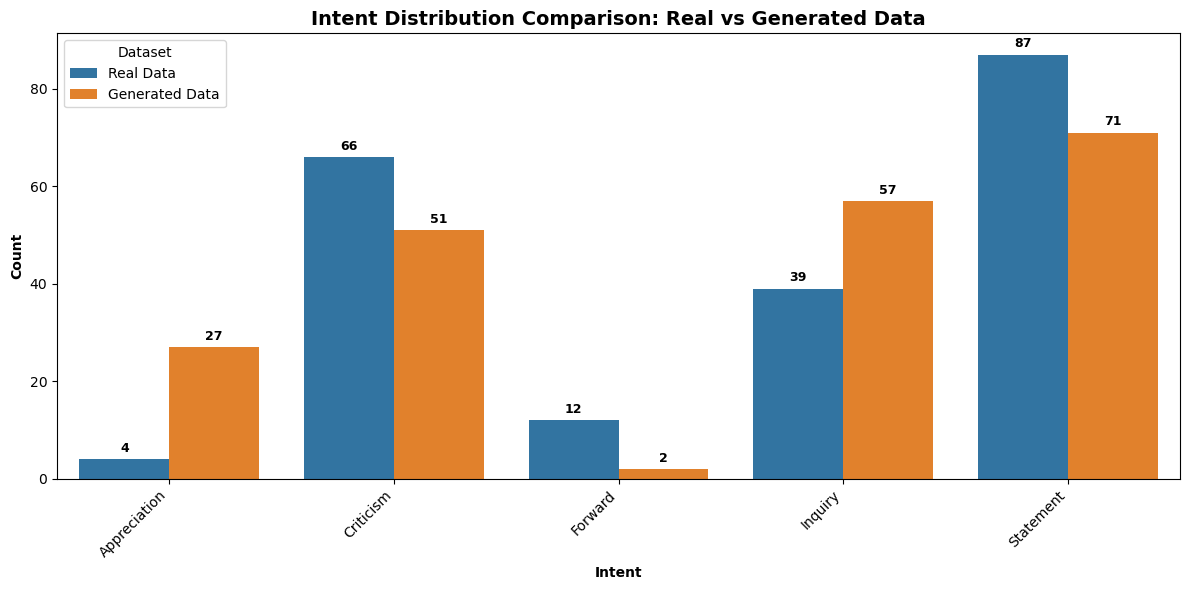

C:\Users\20245179\AppData\Local\Temp\ipykernel_44688\3471970285.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(desired_order, rotation=45, ha='right')


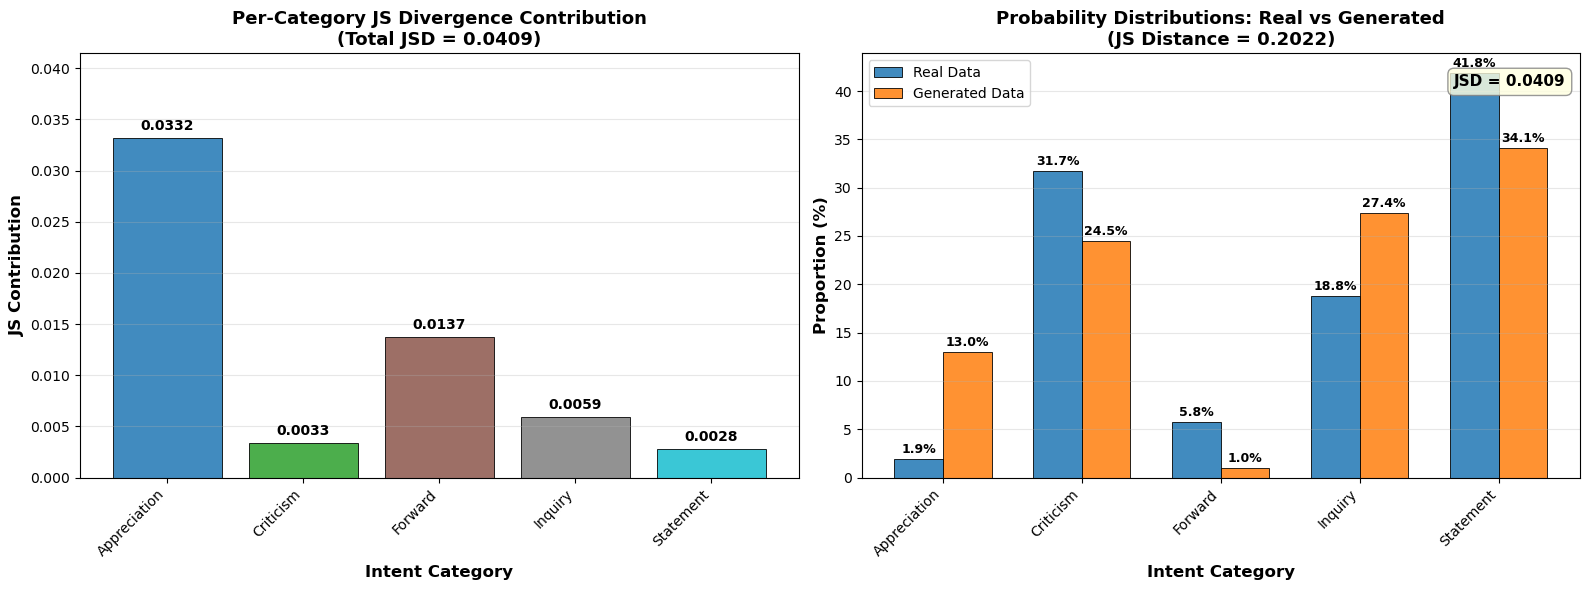

Intent Distribution Comparison:
              Real Count  Real %  Generated Count  Generated %  \
Appreciation           4     1.9               27         13.0   
Criticism             66    31.7               51         24.5   
Forward               12     5.8                2          1.0   
Inquiry               39    18.8               57         27.4   
Statement             87    41.8               71         34.1   

              JS Contribution  
Appreciation           0.0332  
Criticism              0.0033  
Forward                0.0137  
Inquiry                0.0059  
Statement              0.0028  

JS Distance:   0.2022
JS Divergence: 0.0409
Interpretation: Excellent match


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon

# for fine tuned model - test_real
#intent_real = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v13_multitasks_obj_length_dist\intent_predictions_test_real.csv")

#for few shot prompt
intent_real = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine Tune gemma\multiloss\multiloss_intent_predictionsv3.csv")
intents = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine Tune gemma\multiloss\multiloss_intent_predictionsv3.csv")

# Count occurrences for both datasets
real_label_counts = intent_real['True_Intent'].value_counts()

generated_label_counts = intents['final_label_three_models_final'].value_counts()

# Get all unique labels and create a consistent order
all_labels = set(real_label_counts.index.tolist() + generated_label_counts.index.tolist())
desired_order = sorted(all_labels)

# Ensure both datasets have counts for all labels (fill missing with 0)
real_counts = np.array([real_label_counts.get(label, 0) for label in desired_order], dtype=float)
generated_counts = np.array([generated_label_counts.get(label, 0) for label in desired_order], dtype=float)

# Convert to probability distributions
real_probs = real_counts / real_counts.sum()
generated_probs = generated_counts / generated_counts.sum()

# Compute JS Divergence
js_distance = jensenshannon(real_probs, generated_probs)
js_divergence = js_distance ** 2

# ── Plot 1: Original grouped bar plot ─────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Intent': desired_order * 2,
    'Count': list(real_counts) + list(generated_counts),
    'Dataset': ['Real Data'] * len(desired_order) + ['Generated Data'] * len(desired_order)
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=comparison_df, x='Intent', y='Count', hue='Dataset', palette=['#1f77b4', '#ff7f0e'])

for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + max(real_counts.max(), generated_counts.max()) * 0.01,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)


plt.title('Intent Distribution Comparison: Real vs Generated Data', fontweight='bold', fontsize=14)
plt.xlabel('Intent', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# ── Plot 2: Per-category JS contribution + probability comparison ──────────────
def js_contributions(p, q):
    m = 0.5 * (p + q)
    kl_pm = np.where(p > 0, p * np.log2(p / m), 0)
    kl_qm = np.where(q > 0, q * np.log2(q / m), 0)
    return 0.5 * kl_pm + 0.5 * kl_qm

contributions = js_contributions(real_probs, generated_probs)

# Use a color per intent category
palette = plt.cm.tab10(np.linspace(0, 1, len(desired_order)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-category JS contribution
bars = axes[0].bar(desired_order, contributions, color=palette, alpha=0.85, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, contributions):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

axes[0].set_xlabel('Intent Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('JS Contribution', fontsize=12, fontweight='bold')
axes[0].set_title(f'Per-Category JS Divergence Contribution\n(Total JSD = {js_divergence:.4f})', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(desired_order, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(contributions) * 1.25)

# Right: probability distributions side by side
x = np.arange(len(desired_order))
width = 0.35
bars1 = axes[1].bar(x - width/2, real_probs * 100, width, label='Real Data', color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.7)
bars2 = axes[1].bar(x + width/2, generated_probs * 100, width, label='Generated Data', color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=0.7)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.3,
                         f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

axes[1].set_xlabel('Intent Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion (%)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Probability Distributions: Real vs Generated\n(JS Distance = {js_distance:.4f})', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(desired_order, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(0.98, 0.95,
             f'JSD = {js_divergence:.4f}',
             transform=axes[1].transAxes, fontsize=11, fontweight='bold',
             ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig('intent_js_divergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary statistics ─────────────────────────────────────────────────────────
print("Intent Distribution Comparison:")
print("=" * 60)
stats_df = pd.DataFrame({
    'Real Count': real_counts.astype(int),
    'Real %': (real_probs * 100).round(1),
    'Generated Count': generated_counts.astype(int),
    'Generated %': (generated_probs * 100).round(1),
    'JS Contribution': contributions.round(4)
}, index=desired_order)
print(stats_df)
print(f"\nJS Distance:   {js_distance:.4f}")
print(f"JS Divergence: {js_divergence:.4f}")
print(f"Interpretation: {'Excellent match' if js_divergence < 0.05 else 'Good match' if js_divergence < 0.1 else 'Moderate divergence' if js_divergence < 0.2 else 'High divergence'}")

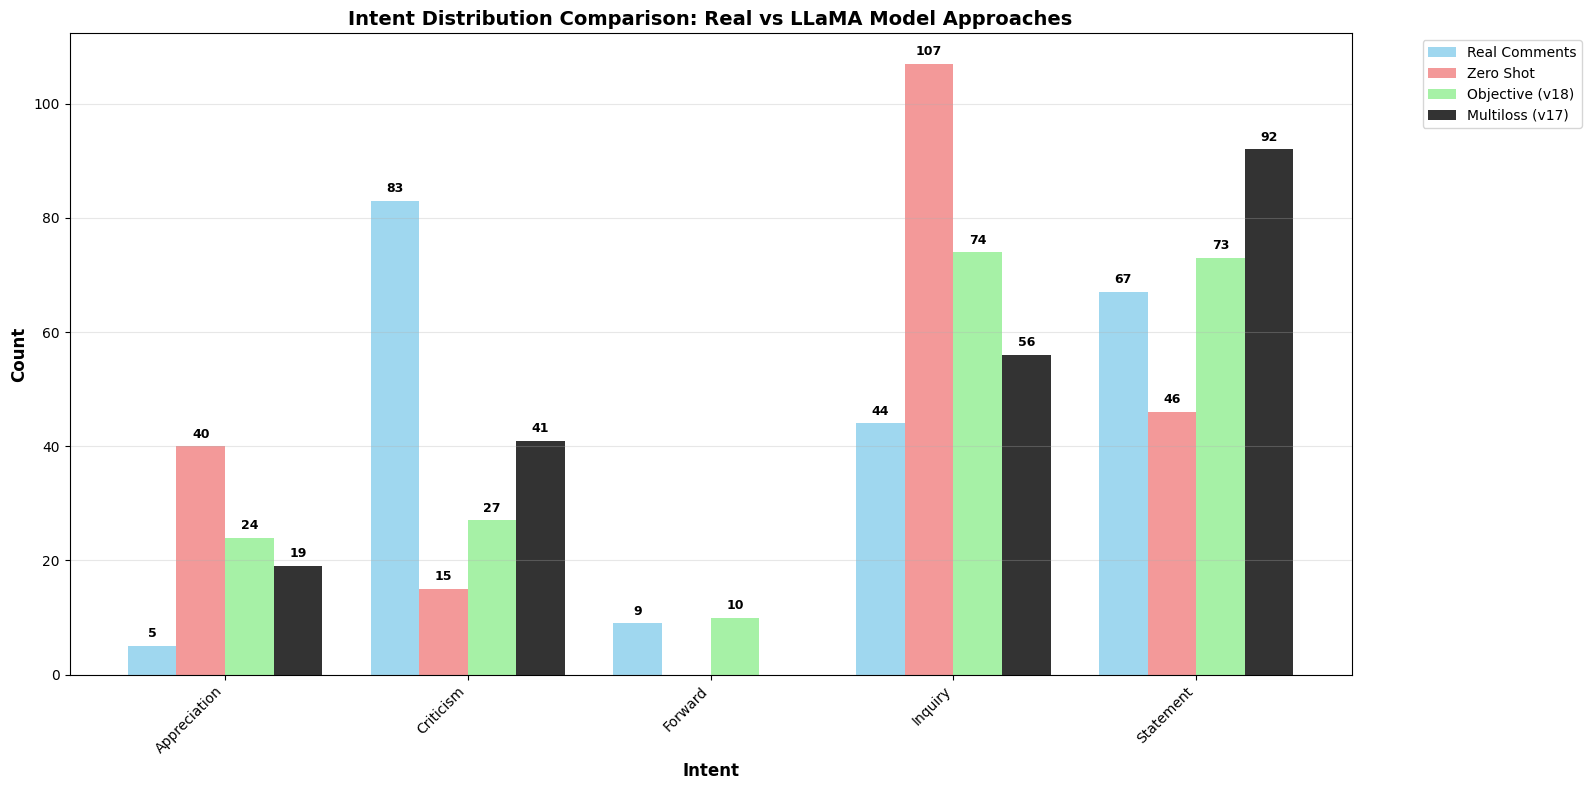

INTENT DISTRIBUTION SUMMARY

Real Comments:
  Appreciation: 5 (2.4%)
  Criticism: 83 (39.9%)
  Forward: 9 (4.3%)
  Inquiry: 44 (21.2%)
  Statement: 67 (32.2%)
  Total: 208

Zero Shot:
  Appreciation: 40 (19.2%)
  Criticism: 15 (7.2%)
  Forward: 0 (0.0%)
  Inquiry: 107 (51.4%)
  Statement: 46 (22.1%)
  Total: 208

Objective (v18):
  Appreciation: 24 (11.5%)
  Criticism: 27 (13.0%)
  Forward: 10 (4.8%)
  Inquiry: 74 (35.6%)
  Statement: 73 (35.1%)
  Total: 208

Multiloss (v17):
  Appreciation: 19 (9.1%)
  Criticism: 41 (19.7%)
  Forward: 0 (0.0%)
  Inquiry: 56 (26.9%)
  Statement: 92 (44.2%)
  Total: 208

PERCENTAGE COMPARISON
Intent          Real       Zero Shot    Objective    Multiloss 
---------------------------------------------------------------------------
Appreciation       2.4%     19.2%        11.5%         9.1%
Criticism         39.9%      7.2%        13.0%        19.7%
Forward            4.3%      0.0%         4.8%         0.0%
Inquiry           21.2%     51.4%        35.6% 

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load datasets
intent_real = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_test_set_classifier_intent_pred.csv")
zero_shot   = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Few Shot Prompt\LLAMA_3.2_3B_Instruct\intent_predictions.csv")
objective   = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v30_objectivee_buurman_new_data\objective_intent_predictionsv2.csv")
multiloss   = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v40_CElossintent_CElosssent_MSE\intent_predictions.csv")


#zero_shot = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Few Shot Prompt\Gemma 4B it\intent_predictions.csv")
#objective = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine Tune gemma\objective\objective_intent_predictionsv2.csv")
#multiloss = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine Tune gemma\multiloss\multiloss_intent_predictionsv3.csv")


#zero_shot = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Few Shot Prompt\fietje\fietje_intent_predictions.csv")
#objective = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_tune_fietje\objective\intent_predictions.csv")
#multiloss = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_tune_fietje\multitask\intent_predictions.csv")

# Count occurrences
real_intent_counts  = intent_real['final_label_three_models_final'].value_counts()
zero_shot_counts    = zero_shot['final_label_three_models_final'].value_counts()
objective_counts    = objective['final_label_three_models_final'].value_counts()
multiloss_counts    = multiloss['final_label_three_models_final'].value_counts()

# Get all unique labels
all_intent_labels = set()
for counts in [real_intent_counts, zero_shot_counts, objective_counts, multiloss_counts]:
    all_intent_labels.update(counts.index.tolist())

desired_intent_order = sorted(all_intent_labels)

# Prepare values
real_values       = [real_intent_counts.get(label, 0) for label in desired_intent_order]
zero_shot_values  = [zero_shot_counts.get(label, 0)   for label in desired_intent_order]
objective_values  = [objective_counts.get(label, 0)   for label in desired_intent_order]
multiloss_values  = [multiloss_counts.get(label, 0)   for label in desired_intent_order]

# Set up the plot
x = np.arange(len(desired_intent_order))
width = 0.2  # Narrower to fit 4 groups

fig, ax = plt.subplots(figsize=(16, 8))

bars1 = ax.bar(x - 1.5*width, real_values,      width, label='Real Comments',   color='skyblue',    alpha=0.8)
bars2 = ax.bar(x - 0.5*width, zero_shot_values, width, label='Zero Shot',        color='lightcoral', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, objective_values, width, label='Objective (v18)', color='lightgreen', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, multiloss_values, width, label='Multiloss (v17)', color='black',     alpha=0.8)

# Add value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Intent', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Intent Distribution Comparison: Real vs LLaMA Model Approaches', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(desired_intent_order, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("INTENT DISTRIBUTION SUMMARY")
print("=" * 60)

intent_datasets = [
    ("Real Comments",   real_values),
    ("Zero Shot",       zero_shot_values),
    ("Objective (v18)", objective_values),
    ("Multiloss (v17)", multiloss_values),
]

for dataset_name, values in intent_datasets:
    print(f"\n{dataset_name}:")
    total = sum(values)
    for intent, count in zip(desired_intent_order, values):
        percentage = (count / total) * 100 if total > 0 else 0
        print(f"  {intent}: {count} ({percentage:.1f}%)")
    print(f"  Total: {total}")

# Percentage comparison table
print(f"\n{'PERCENTAGE COMPARISON'}")
print("=" * 75)
print(f"{'Intent':<15} {'Real':<10} {'Zero Shot':<12} {'Objective':<12} {'Multiloss':<10}")
print("-" * 75)

for i, intent in enumerate(desired_intent_order):
    real_pct      = (real_values[i]      / sum(real_values))      * 100 if sum(real_values)      > 0 else 0
    zero_shot_pct = (zero_shot_values[i] / sum(zero_shot_values)) * 100 if sum(zero_shot_values) > 0 else 0
    objective_pct = (objective_values[i] / sum(objective_values)) * 100 if sum(objective_values) > 0 else 0
    multiloss_pct = (multiloss_values[i] / sum(multiloss_values)) * 100 if sum(multiloss_values) > 0 else 0

    print(f"{intent:<15} {real_pct:>6.1f}%   {zero_shot_pct:>6.1f}%      {objective_pct:>6.1f}%      {multiloss_pct:>6.1f}%")


In [8]:
from scipy.spatial.distance import jensenshannon
import numpy as np
import pandas as pd

# Convert counts to probability distributions
real_arr      = np.array(real_values,      dtype=float)
zero_shot_arr = np.array(zero_shot_values, dtype=float)
objective_arr = np.array(objective_values, dtype=float)
multiloss_arr = np.array(multiloss_values, dtype=float)

real_probs      = real_arr      / real_arr.sum()
zero_shot_probs = zero_shot_arr / zero_shot_arr.sum()
objective_probs = objective_arr / objective_arr.sum()
multiloss_probs = multiloss_arr / multiloss_arr.sum()

gen_models = [
    ("Zero Shot",       zero_shot_probs),
    ("Objective (v30)", objective_probs),
    ("Multiloss (v39)", multiloss_probs),
]

rows = []
for model_name, gen_probs in gen_models:
    js_dist = jensenshannon(real_probs, gen_probs)
    js_div  = js_dist ** 2

    row = {"Model": model_name, "JS Distance": round(js_dist, 6), "JS Divergence (²)": round(js_div, 6)}
    for i, intent in enumerate(desired_intent_order):
        row[f"Real % {intent}"] = round(real_probs[i] * 100, 1)
        row[f"Gen % {intent}"]  = round(gen_probs[i]  * 100, 1)
        row[f"Δ {intent}"]      = round(abs(gen_probs[i] - real_probs[i]) * 100, 1)

    row["Interpretation"] = (
        "Excellent match"     if js_div < 0.05 else
        "Good match"          if js_div < 0.10 else
        "Moderate divergence" if js_div < 0.20 else
        "High divergence"
    )
    rows.append(row)

js_table = pd.DataFrame(rows).set_index("Model")

print("=" * 80)
print("JENSEN-SHANNON DIVERGENCE: INTENT DISTRIBUTION vs REAL COMMENTS")
print("=" * 80)
print(js_table.to_string())
print()
print("Note: JS Distance ∈ [0, 1] — 0 = identical, 1 = completely different")
print("      JS Divergence = JS Distance²")

js_table

JENSEN-SHANNON DIVERGENCE: INTENT DISTRIBUTION vs REAL COMMENTS
                 JS Distance  JS Divergence (²)  Real % Appreciation  Gen % Appreciation  Δ Appreciation  Real % Criticism  Gen % Criticism  Δ Criticism  Real % Forward  Gen % Forward  Δ Forward  Real % Inquiry  Gen % Inquiry  Δ Inquiry  Real % Statement  Gen % Statement  Δ Statement       Interpretation
Model                                                                                                                                                                                                                                                                                                            
Zero Shot           0.389879           0.152006                  2.4                19.2            16.8              39.9              7.2         32.7             4.3            0.0        4.3            21.2           51.4       30.3              32.2             22.1         10.1  Moderate divergence
Objective (v30)   

,JS Distance,JS Divergence (²),Real % Appreciation,Gen % Appreciation,Δ Appreciation,Real % Criticism,Gen % Criticism,Δ Criticism,Real % Forward,Gen % Forward,Δ Forward,Real % Inquiry,Gen % Inquiry,Δ Inquiry,Real % Statement,Gen % Statement,Δ Statement,Interpretation
Model,,,,,,,,,,,,,,,,,,
Zero Shot,0.389879,0.152006,2.4,19.2,16.8,39.9,7.2,32.7,4.3,0.0,4.3,21.2,51.4,30.3,32.2,22.1,10.1,Moderate divergence
Objective (v30),0.248677,0.061840,2.4,11.5,9.1,39.9,13.0,26.9,4.3,4.8,0.5,21.2,35.6,14.4,32.2,35.1,2.9,Good match
Multiloss (v39),0.222221,0.049382,2.4,9.1,6.7,39.9,19.7,20.2,4.3,0.0,4.3,21.2,26.9,5.8,32.2,44.2,12.0,Excellent match
